# PCA + t-SNE on Wine Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [3]:
# Load the wine dataset
from sklearn.datasets import load_wine
wine = load_wine()
X = wine.data
y = wine.target



In [4]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# PCA analysis
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)


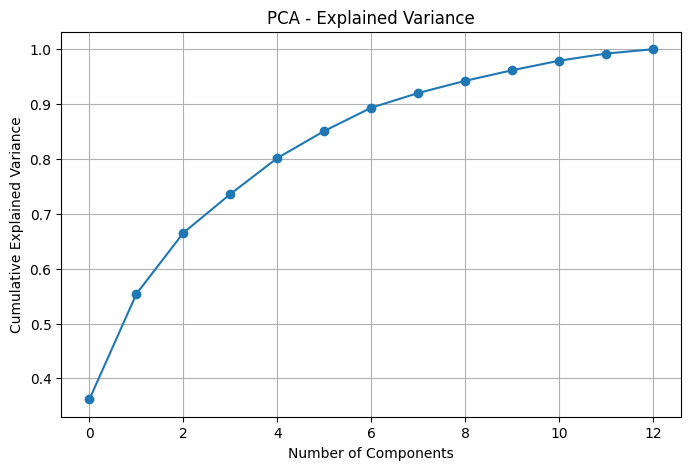

In [6]:
# plot cumulative variance
plt.figure(figsize=(8,5))
plt.plot(cumulative_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance')
plt.grid()
plt.show()

In [22]:
# Choose number of components (e.g. 95% threshold)
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Optimal number of components (95% variance): {n_components}")

Optimal number of components (95% variance): 10


In [8]:
# Apply PCA with selected components
pca = PCA(n_components=n_components)
X_pca_reduced = pca.fit_transform(X_scaled)

In [9]:
# LOGISTIC REGRESSION
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [10]:
# Original data
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
acc_original = accuracy_score(y_test, y_pred)

# PCA data
X_train_pca, X_test_pca, _, _ = train_test_split(
    X_pca_reduced, y, test_size=0.2, random_state=42
)

lr.fit(X_train_pca, y_train)
y_pred_pca = lr.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

print(f"Accuracy (Original): {acc_original:.4f}")
print(f"Accuracy (PCA): {acc_pca:.4f}")

Accuracy (Original): 1.0000
Accuracy (PCA): 1.0000


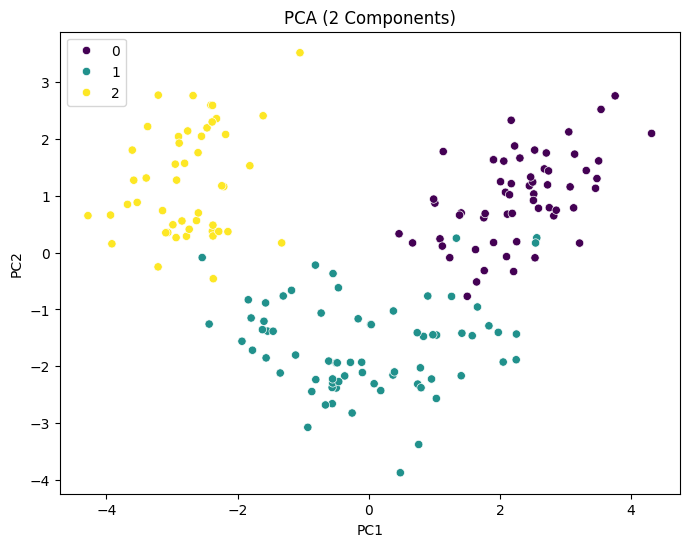

In [11]:
# PCA VISUALIZATION (2D)

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca_2d[:,0],
    y=X_pca_2d[:,1],
    hue=y,
    palette='viridis'
)
plt.title("PCA (2 Components)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

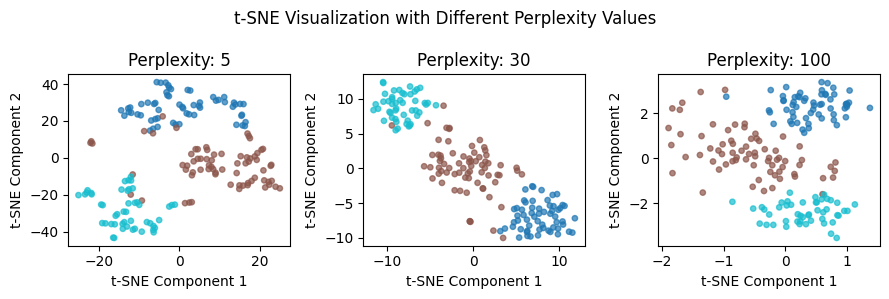

In [21]:
# t-SNE ANALYSIS

from matplotlib.pyplot import axes


perplexities = [5, 30, 100]
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

X_sub = X_scaled
y_sub = y

for ax, perp in zip(axes, perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, max_iter=500, random_state=42)
    X_tsne = tsne.fit_transform(X_sub)

    scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sub, cmap='tab10', alpha=0.7, s=15)
    ax.set_title(f"Perplexity: {perp}")
    ax.set_xlabel("t-SNE Component 1")
    ax.set_ylabel("t-SNE Component 2")

    
plt.suptitle("t-SNE Visualization with Different Perplexity Values")
plt.tight_layout()  
plt.show()
